실습 5. 종합 분석 리포트
- 한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

목표
- 배운 도구로 한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

단계
- 추세와 변동성 그래프를 그리고 의심 구간을 표시
- 상관 heatmap으로 센서 관계를 확인
- 사실과 해석을 구분한 짧은 리포트 출력

예상 결과
- 그래프·heatmap과 함께 사실·해석이 구분된 미니 리포트

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/21_cmapss_fd001_sample.csv')
print(df.shape)

sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

(1031, 10)


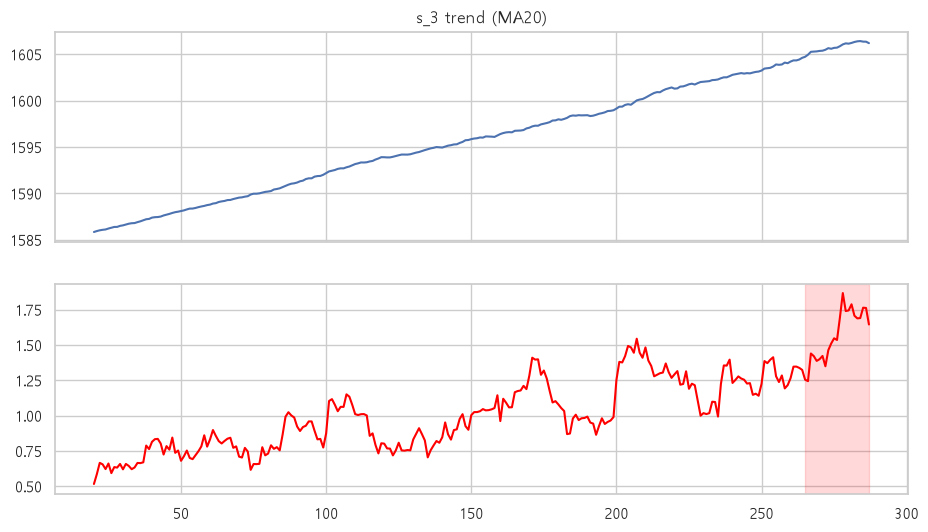

[사실] s_3 변동성이 후반부(265주기 이후) 증가
[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93
[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고


In [ ]:
# [통계 및 시각화 근거 기반 설비 보전 의사결정 요청용 종합 리포트 생성]
# 1. axes[0].plot(): 20-사이클 이동평균선(ma)을 통해 온도/마찰 센서의 지속적인 우상향(추세)을 증명합니다.
# 2. axes[1].plot() 및 axvspan(): 후반부(265~287 사이클)에 발생한 진폭 팽창(변동성 급증) 현상을 차트상에 경고 박스로 매핑합니다.
# 3. 종합 인쇄문: 앞서 발견한 정량 사실들(상관행렬 결과, 변동 구간)을 텍스트로 구성하고 최종 정비 권고안을 현장에 송출합니다.
# * 머신러닝이나 수식을 통한 기계 예측 과정에서 수치뿐 아니라 원인과 경과를 설명할 수 있는
#   '설명 가능한(Explainable) 예방보전'의 기초 형태를 텍스트 및 차트 리포트로 자동 생성해 줍니다.
# * 리포트 문자열 출력 시, 줄바꿈이나 오타로 인해 코드 블록 문법이 망가지지 않도록 세심하게 텍스트를 인쇄합니다.
eng_02 = df[df['unit_nr'] == 2].reset_index(drop=True)

ma = eng_02['s_3'].rolling(20).mean()
sd2 = eng_02['s_3'].rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(eng_02['time_cycles'], ma); axes[0].set_title('s_3 trend (MA20)')
axes[1].plot(eng_02['time_cycles'], sd2, color='red')
axes[1].axvspan(265, 287, color='red', alpha=0.15)

plt.show()

# 사실과 해석을 구분한 짧은 리포트 출력
print('[사실] s_3 변동성이 후반부(265주기 이후) 증가')
print('[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93')
print('[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고')